In [2]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, print_metrics, plot_regression_results, evaluate_minirocket_vitaldb, train_mlp, select_top_pearson_features

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=625,
    STEP_SIZE=625
)

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/5sec_0overlap/vitaldb_checkpoints"

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [01:35<00:00, 100.56it/s]


Skipped recordings: 96


100%|██████████| 1200/1200 [00:12<00:00, 95.73it/s] 


Skipped recordings: 7


100%|██████████| 1200/1200 [00:12<00:00, 96.52it/s] 

Skipped recordings: 9


In [5]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (417030, 1, 625)
y_train: (417030, 2)
X_val: (52650, 1, 625)
y_val: (52650, 2)
X_test: (52863, 1, 625)
y_test: (52863, 2)


In [6]:
from sktime.transformations.panel.rocket import MiniRocket

rocket = MiniRocket(num_kernels=5000, random_state=42)

rocket.fit(X_train)

MiniRocket(num_kernels=5000, random_state=42)

In [7]:
def transform_to_disk(rocket, X, path, bs=2000):
    d = rocket.transform(X[:2]).shape[1]
    out = np.lib.format.open_memmap(path, mode="w+", dtype=np.float32, shape=(len(X), d))
    for i in tqdm(range(0, len(X), bs)):
        out[i:i+bs] = rocket.transform(X[i:i+bs]).to_numpy(dtype=np.float32)
    out.flush()
    return out

transform_to_disk(rocket, X_train, "X_train_minirocket.npy")
transform_to_disk(rocket, X_val,   "X_val_minirocket.npy")
transform_to_disk(rocket, X_test,  "X_test_minirocket.npy")
del X_train, X_val, X_test; import gc; gc.collect()   # raw windows no longer needed

100%|██████████| 27/27 [00:24<00:00,  1.10it/s]


2381

In [8]:
X_train_rocket = np.load("X_train_minirocket.npy", mmap_mode="r")
X_val_rocket   = np.load("X_val_minirocket.npy",   mmap_mode="r")
X_test_rocket  = np.load("X_test_minirocket.npy",  mmap_mode="r")

In [9]:
y_train_sbp = y_train[:, 0]
y_train_dbp = y_train[:, 1]

y_val_sbp = y_val[:, 0]
y_val_dbp = y_val[:, 1]

y_test_sbp = y_test[:, 0]
y_test_dbp = y_test[:, 1]

## RIDGE REGRESSION ##

In [10]:
class RidgeModel:
    def __init__(s, mu, sd, W, ym, col): s.mu, s.sd, s.W, s.ym, s.col = mu, sd, W, ym, col
    def predict(s, X):
        X = np.asarray(X, dtype=np.float32)
        return ((X - s.mu) / s.sd) @ s.W[:, s.col] + s.ym[s.col]

def ridge_stats(X, Y, bs=5000):
    n, d = X.shape
    XtX = np.zeros((d, d)); Xty = np.zeros((d, Y.shape[1]))
    sx = np.zeros(d); sy = np.zeros(Y.shape[1])
    for i in tqdm(range(0, n, bs)):
        xb = np.asarray(X[i:i+bs], dtype=np.float64); yb = Y[i:i+bs].astype(np.float64)
        XtX += xb.T @ xb; Xty += xb.T @ yb; sx += xb.sum(0); sy += yb.sum(0)
    return XtX, Xty, sx, sy, n

def solve_ridge(stats, alpha):
    XtX, Xty, sx, sy, n = stats
    mu, ym = sx / n, sy / n
    C = XtX - n * np.outer(mu, mu)
    sd = np.sqrt(np.diag(C) / n); sd[sd == 0] = 1
    C = C / np.outer(sd, sd)
    c = (Xty - n * np.outer(mu, ym)) / sd[:, None]
    W = np.linalg.solve(C + alpha * np.eye(len(mu)), c)
    return mu.astype(np.float32), sd.astype(np.float32), W.astype(np.float32), ym.astype(np.float32)

stats = ridge_stats(X_train_rocket, y_train)

best = {}
for col, name in [(0, "SBP"), (1, "DBP")]:
    scores = {}
    for a in [0.01, 0.1, 1, 10, 100, 1000, 10000]:
        mu, sd, W, ym = solve_ridge(stats, a)
        m = RidgeModel(mu, sd, W, ym, col)
        pred = np.concatenate([m.predict(X_val_rocket[i:i+5000]) for i in range(0, len(X_val_rocket), 5000)])
        scores[a] = np.sqrt(np.mean((pred - y_val[:, col])**2))
    a_best = min(scores, key=scores.get)
    print(name, "best alpha:", a_best, "val RMSE:", scores[a_best])
    best[name] = RidgeModel(*solve_ridge(stats, a_best), col)

grid_ridge_sbp, grid_ridge_dbp = best["SBP"], best["DBP"]

100%|██████████| 84/84 [00:30<00:00,  2.73it/s]


SBP best alpha: 10000 val RMSE: 17.311419
DBP best alpha: 10000 val RMSE: 8.8290615


In [11]:
def batch_predict(m, X, bs=5000):
    return np.concatenate([m.predict(X[i:i+bs]) for i in range(0, len(X), bs)])

y_pred_sbp = batch_predict(grid_ridge_sbp, X_test_rocket)
y_pred_dbp = batch_predict(grid_ridge_dbp, X_test_rocket)

In [12]:
print("MiniRocket + Ridge — SBP")
print("------------------------")
print_metrics(y_test_sbp, y_pred_sbp)

print("\nMiniRocket + Ridge — DBP")
print("------------------------")
print_metrics(y_test_dbp, y_pred_dbp)

MiniRocket + Ridge — SBP
------------------------
RMSE: 17.6991
MSE : 313.2581
R²  : 0.4069
MAE : 13.5463

MiniRocket + Ridge — DBP
------------------------
RMSE: 9.0641
MSE : 82.1581
R²  : 0.3439
MAE : 6.6255


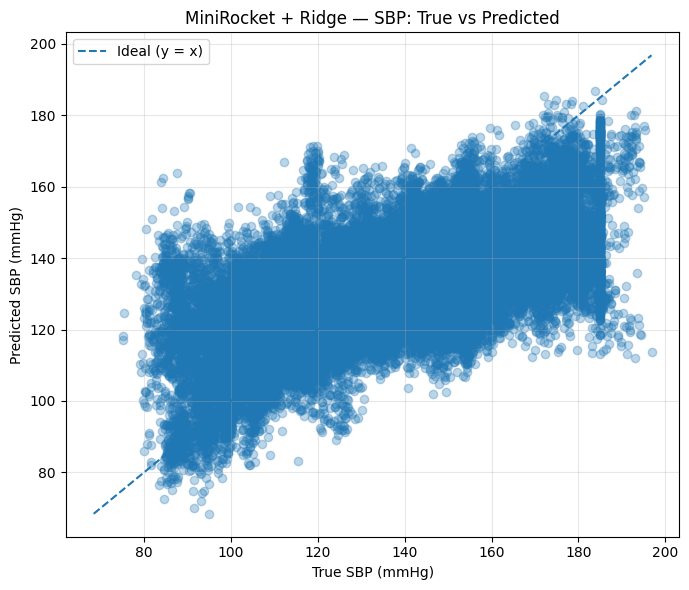

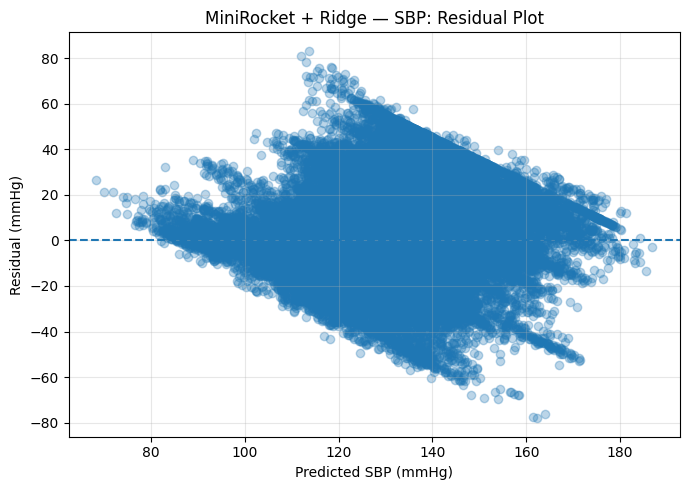

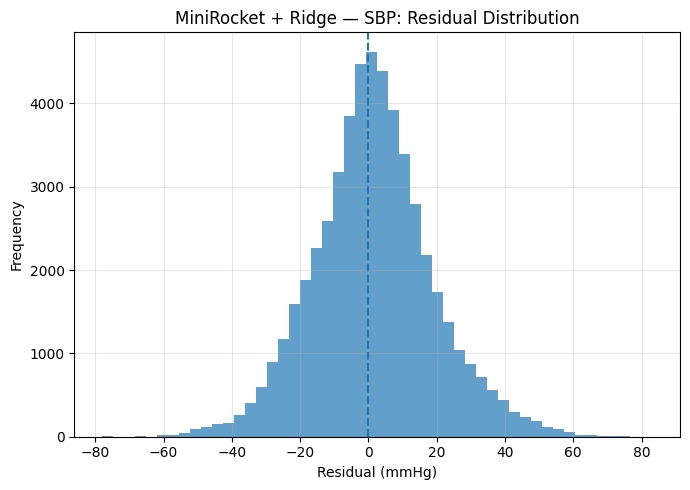

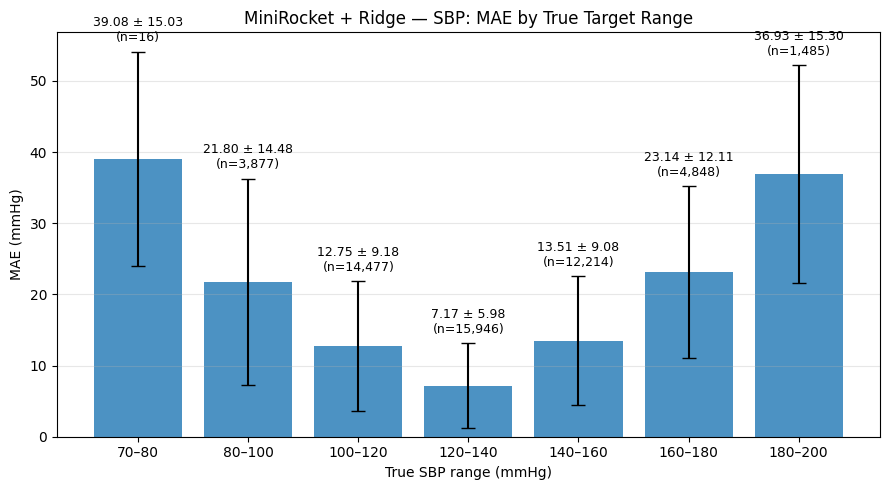

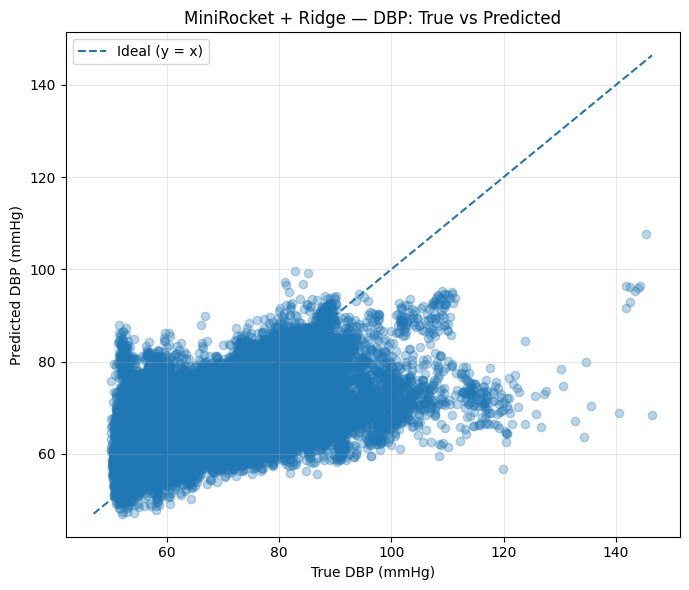

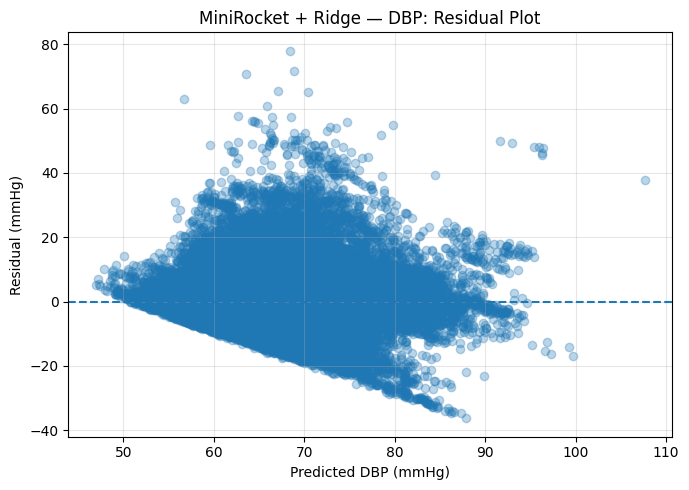

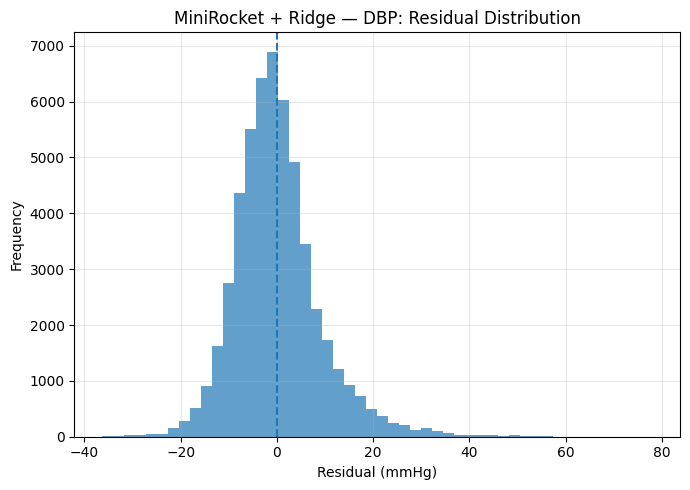

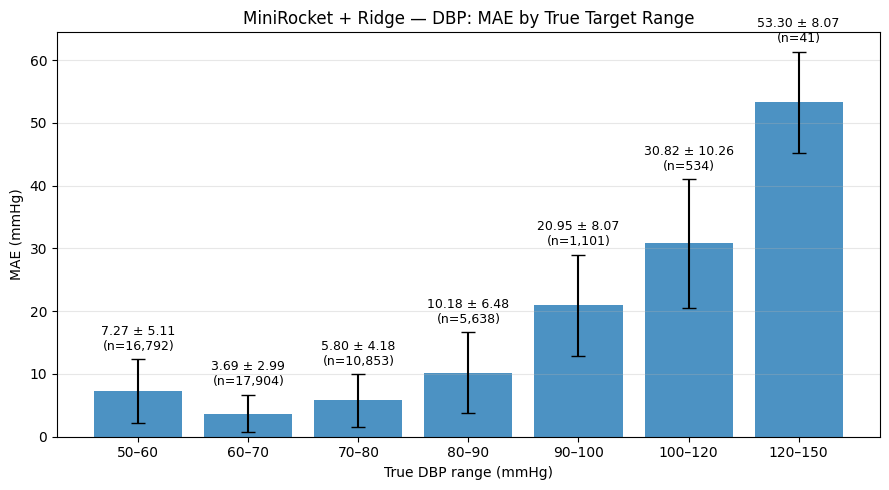

In [13]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + Ridge",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + Ridge",
    "DBP"
)

Number of VitalDB cases: 1961


MiniROCKET VitalDB prediction: 100%|██████████| 1961/1961 [40:38<00:00,  1.24s/case] 




MiniROCKET + Ridge
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 24.2348
MSE : 587.3259
R²  : -0.3784
MAE : 18.9910

DBP
------------------------------
RMSE: 13.6851
MSE : 187.2808
R²  : -0.1506
MAE : 10.7709


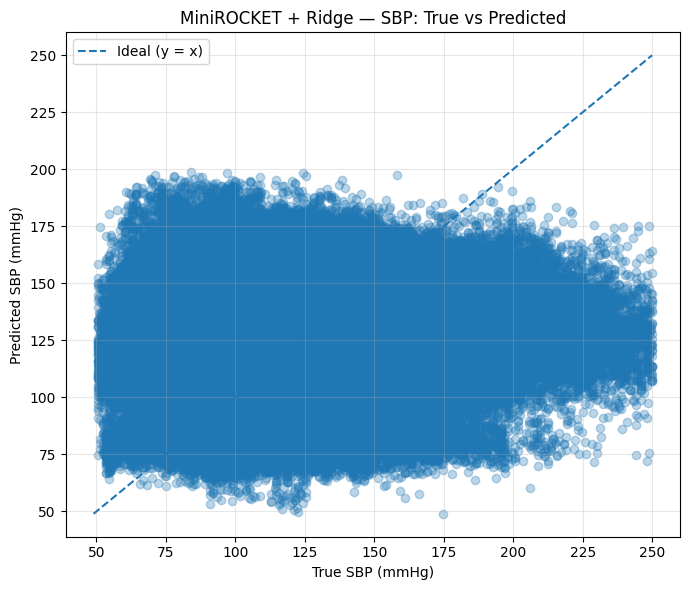

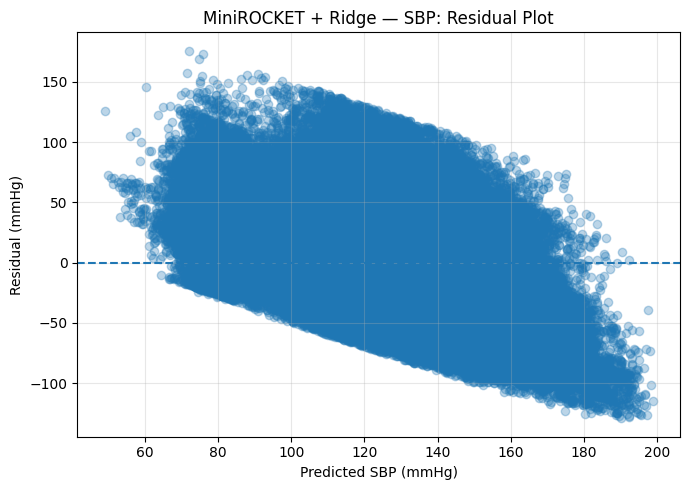

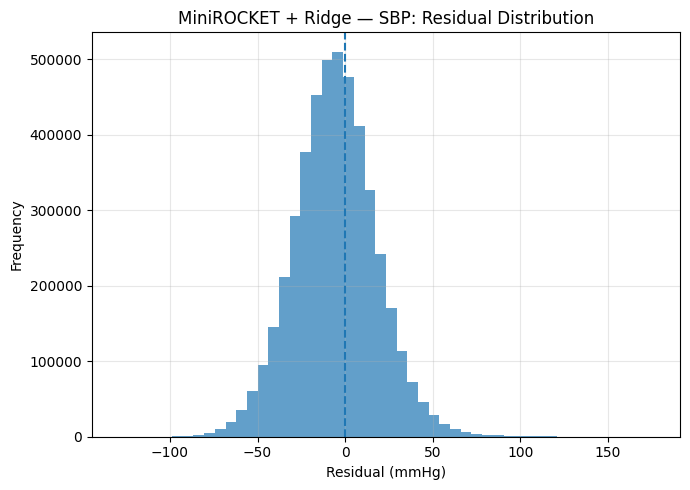

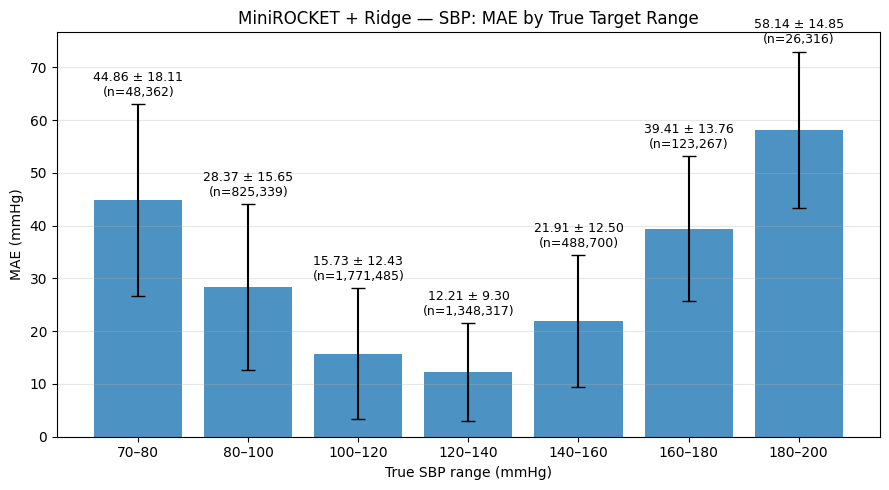

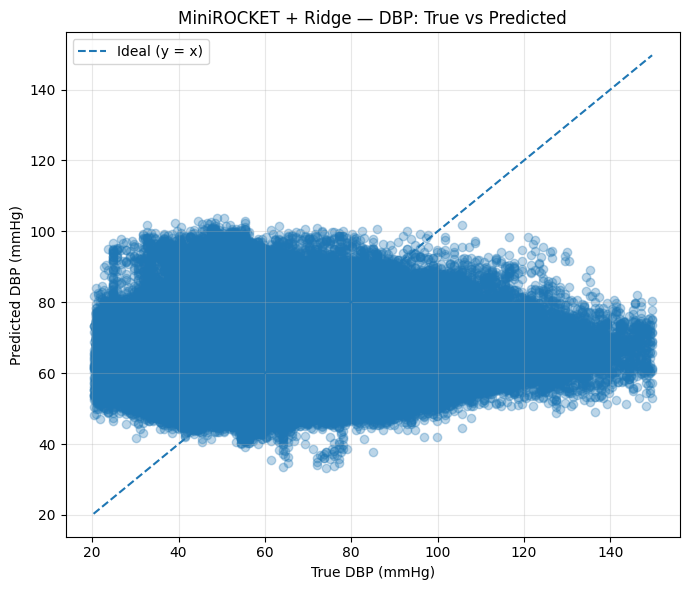

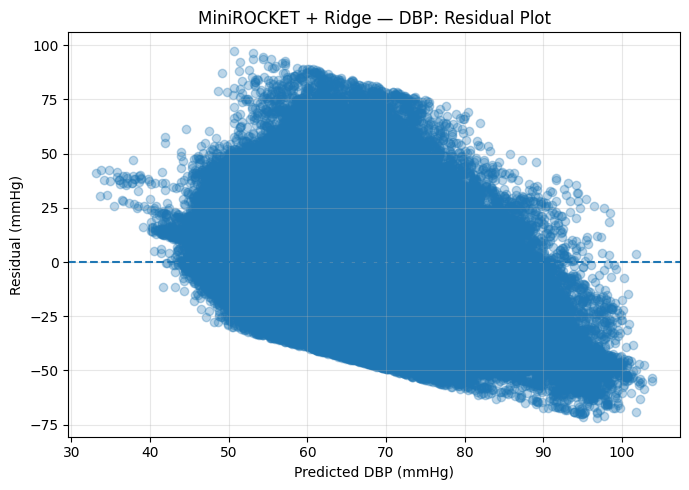

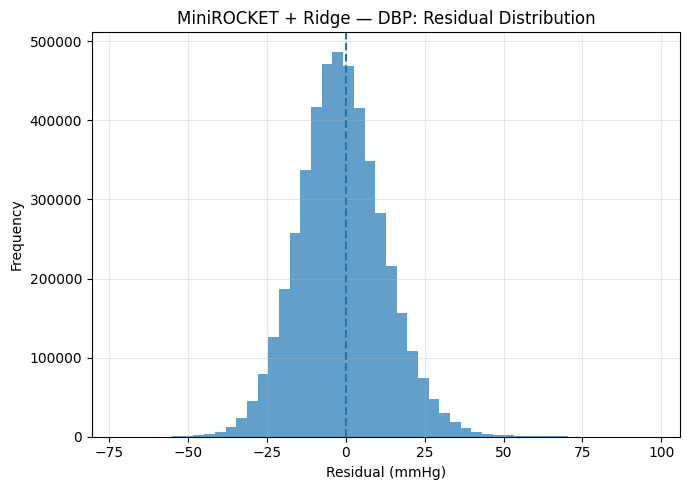

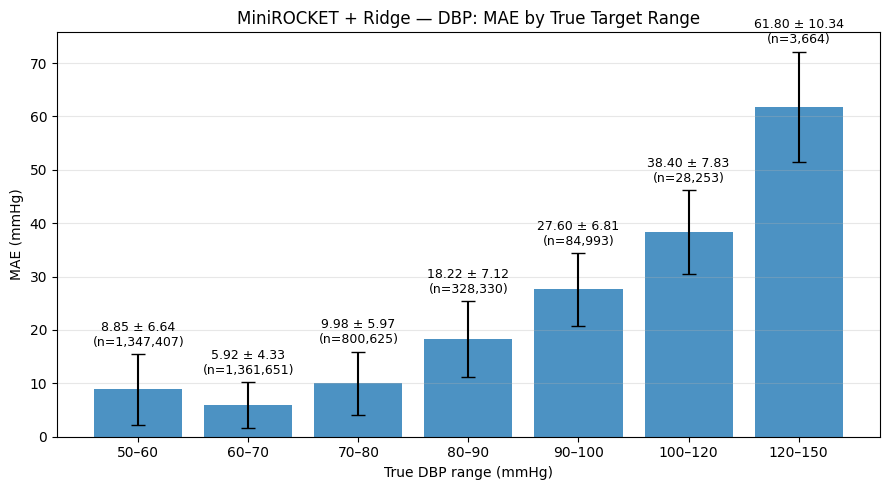


Final prediction shape:
(4651395, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  171.894928  121.010773  75.124176  56.873138
1  case_1  169.920013  116.325554  76.605347  56.255779
2  case_1  168.932587  122.900093  76.111603  58.205208
3  case_1  170.907501  120.252632  74.136719  57.070450
4  case_1  168.932587  124.490021  75.617889  59.889782


In [14]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR,
    rocket=rocket,
    best_en_sbp=grid_ridge_sbp,
    best_en_dbp=grid_ridge_dbp,
    model = "Ridge",
    batch_size=5000
)

## MLP ##

In [15]:
mlp_sbp, mlp_dbp = train_mlp(X_train_rocket, y_train, X_val_rocket, y_val)

epoch 00 | TRAIN loss 0.2366 MSE(SBP 257.52, DBP 71.74) RMSE(SBP 16.05, DBP 8.47) | VAL loss 0.2663 MSE(SBP 298.90, DBP 78.91) RMSE(SBP 17.29, DBP 8.88)


epoch 01 | TRAIN loss 0.2090 MSE(SBP 222.81, DBP 64.54) RMSE(SBP 14.93, DBP 8.03) | VAL loss 0.2516 MSE(SBP 279.65, DBP 75.13) RMSE(SBP 16.72, DBP 8.67)


epoch 02 | TRAIN loss 0.1910 MSE(SBP 199.42, DBP 59.53) RMSE(SBP 14.12, DBP 7.72) | VAL loss 0.2414 MSE(SBP 263.15, DBP 72.61) RMSE(SBP 16.22, DBP 8.52)


epoch 03 | TRAIN loss 0.1794 MSE(SBP 185.19, DBP 55.84) RMSE(SBP 13.61, DBP 7.47) | VAL loss 0.2355 MSE(SBP 253.53, DBP 71.35) RMSE(SBP 15.92, DBP 8.45)


epoch 04 | TRAIN loss 0.1703 MSE(SBP 174.03, DBP 53.79) RMSE(SBP 13.19, DBP 7.33) | VAL loss 0.2341 MSE(SBP 248.10, DBP 73.37) RMSE(SBP 15.75, DBP 8.57)


...

epoch 25 | TRAIN loss 0.0982 MSE(SBP 93.45, DBP 31.63) RMSE(SBP 9.67, DBP 5.62) | VAL loss 0.2031 MSE(SBP 210.77, DBP 63.20) RMSE(SBP 14.52, DBP 7.95)


epoch 26 | TRAIN loss 0.0968 MSE(SBP 91.84, DBP 31.15) RMSE(SBP 9.58, DBP 5.58) | VAL loss 0.2043 MSE(SBP 210.82, DBP 64.10) RMSE(SBP 14.52, DBP 8.01)


epoch 27 | TRAIN loss 0.0954 MSE(SBP 90.49, DBP 30.73) RMSE(SBP 9.51, DBP 5.54) | VAL loss 0.2011 MSE(SBP 207.64, DBP 63.05) RMSE(SBP 14.41, DBP 7.94)


epoch 28 | TRAIN loss 0.0951 MSE(SBP 90.19, DBP 30.63) RMSE(SBP 9.50, DBP 5.53) | VAL loss 0.2009 MSE(SBP 207.20, DBP 63.09) RMSE(SBP 14.39, DBP 7.94)


epoch 29 | TRAIN loss 0.0942 MSE(SBP 88.94, DBP 30.67) RMSE(SBP 9.43, DBP 5.54) | VAL loss 0.2017 MSE(SBP 208.82, DBP 63.30) RMSE(SBP 14.45, DBP 7.96)


In [16]:
y_pred_sbp = batch_predict(mlp_sbp, X_test_rocket)
y_pred_dbp = batch_predict(mlp_dbp, X_test_rocket)
print_metrics(y_test[:, 0], y_pred_sbp)
print_metrics(y_test[:, 1], y_pred_dbp)

RMSE: 15.6447
MSE : 244.7566
R²  : 0.5366
MAE : 10.9002
RMSE: 8.2530
MSE : 68.1122
R²  : 0.4561
MAE : 5.5174


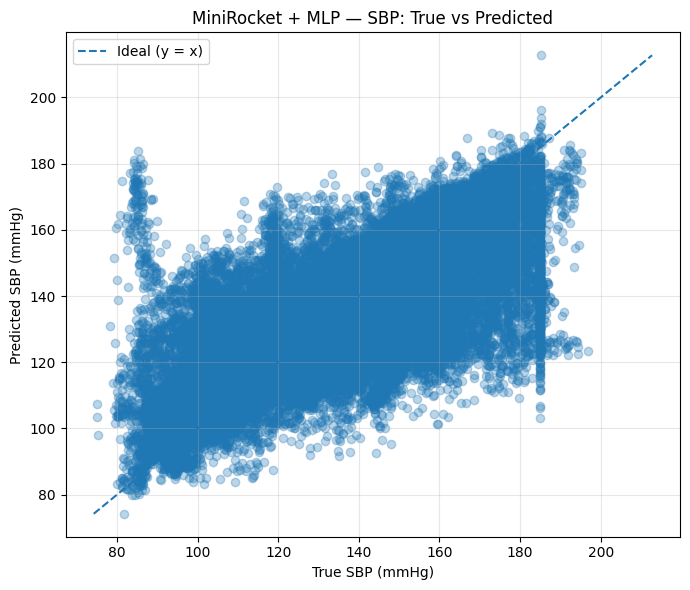

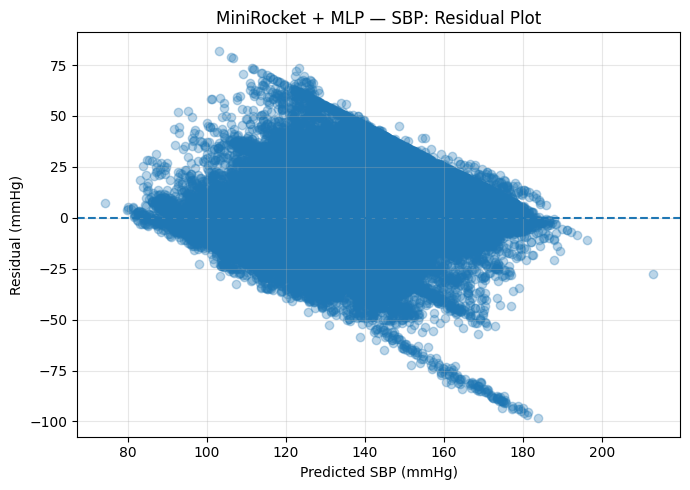

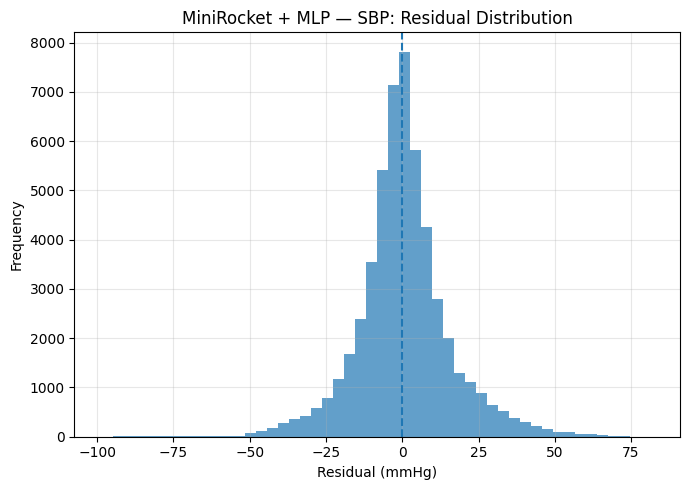

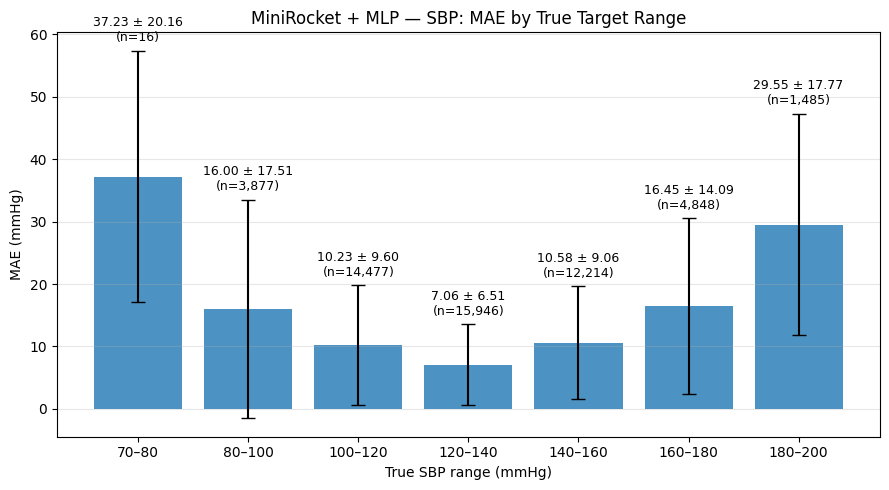

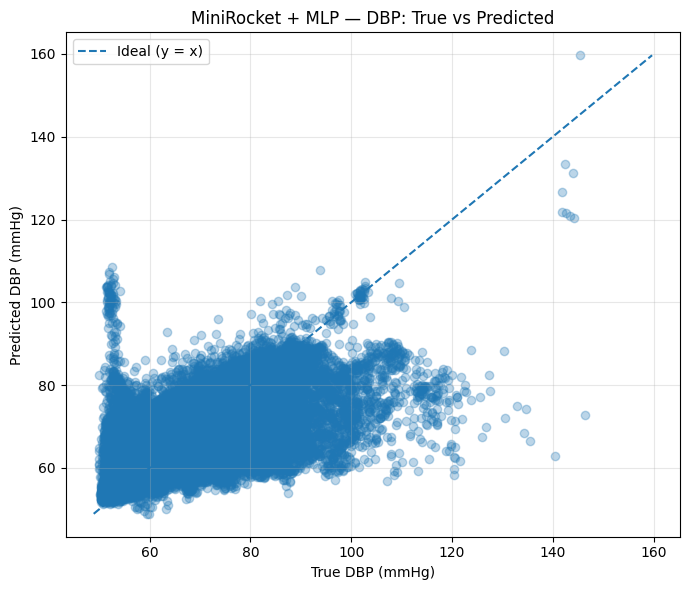

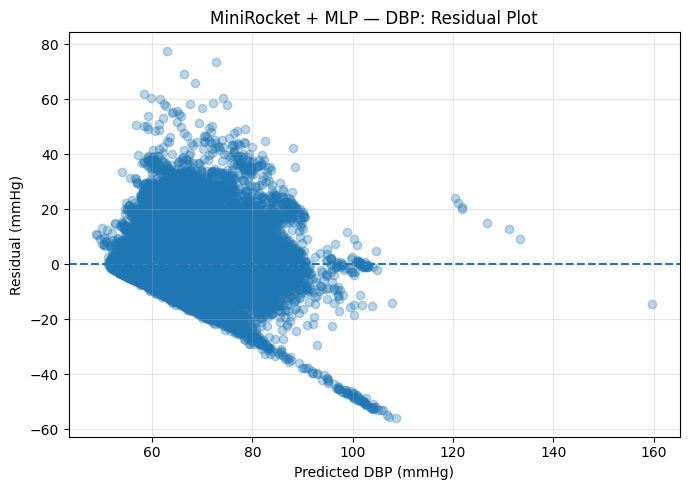

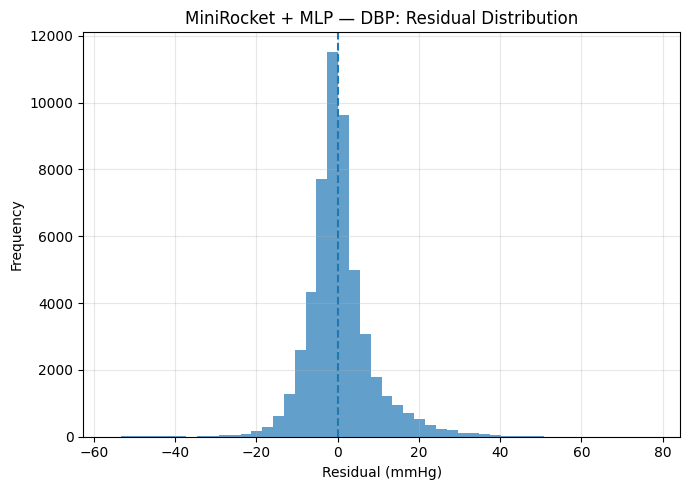

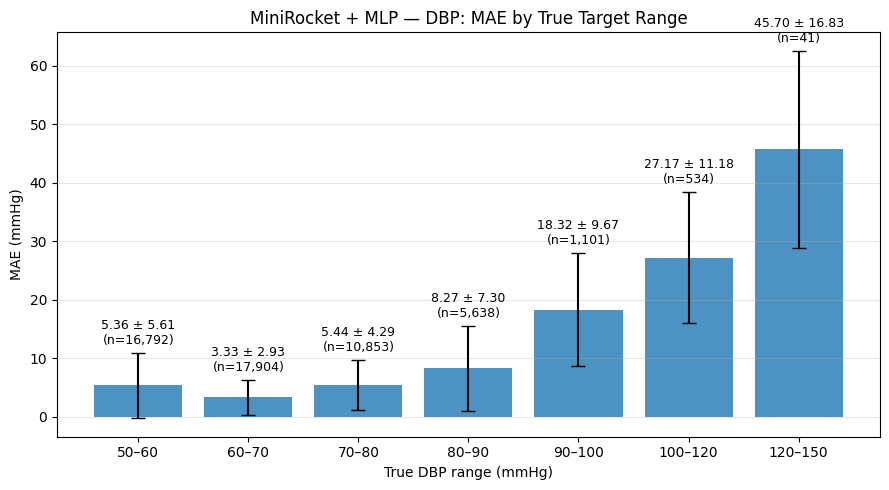

In [17]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + MLP",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + MLP",
    "DBP"
)

Number of VitalDB cases: 1961


MiniROCKET VitalDB prediction: 100%|██████████| 1961/1961 [36:12<00:00,  1.11s/case] 




MiniROCKET + MLP
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 24.6904
MSE : 609.6144
R²  : -0.4307
MAE : 19.7783

DBP
------------------------------
RMSE: 13.1705
MSE : 173.4618
R²  : -0.0657
MAE : 10.4698


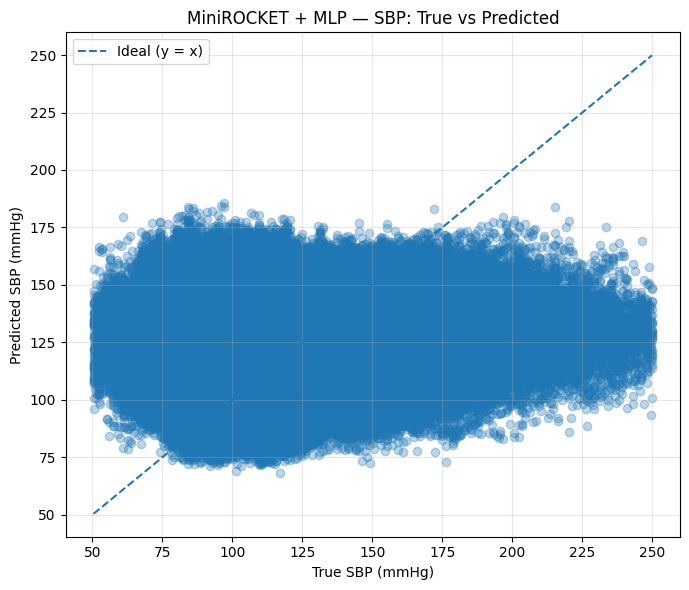

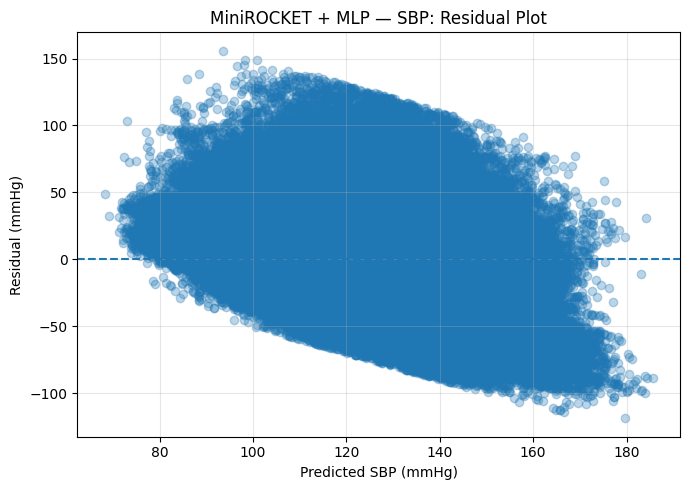

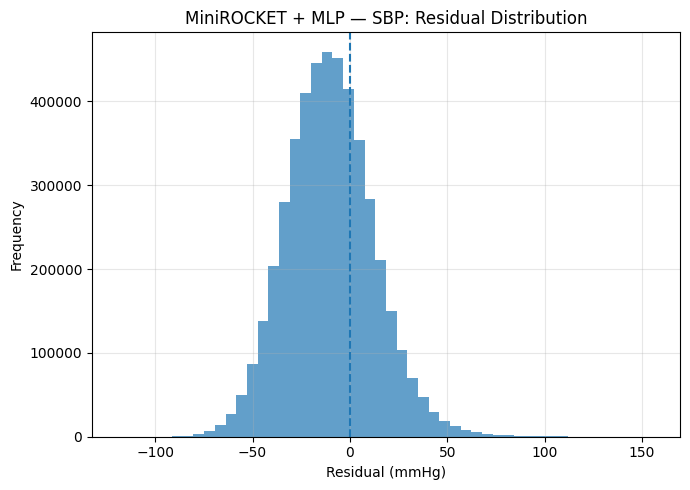

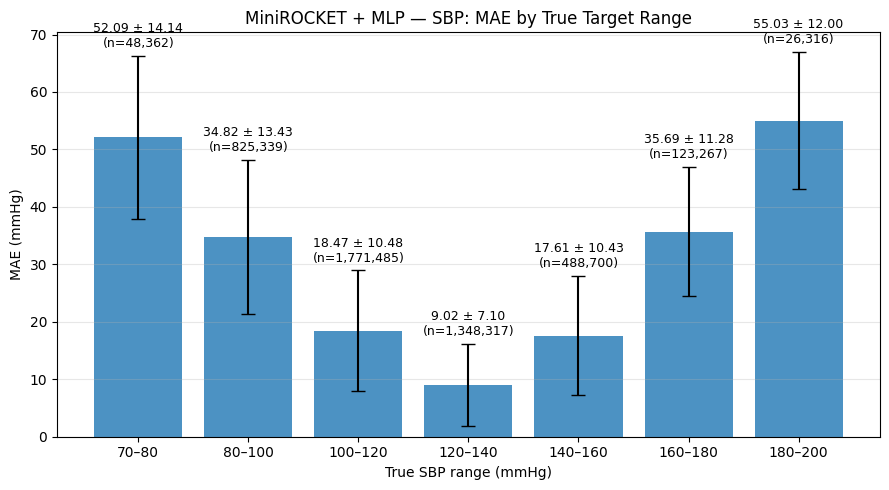

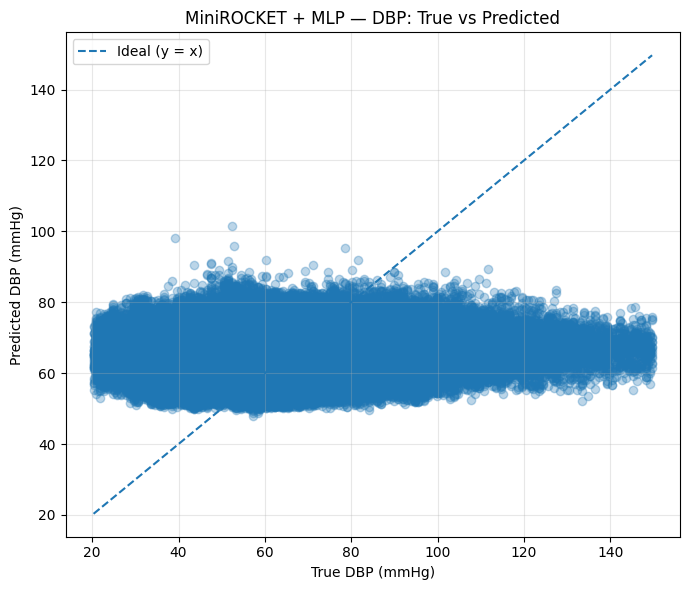

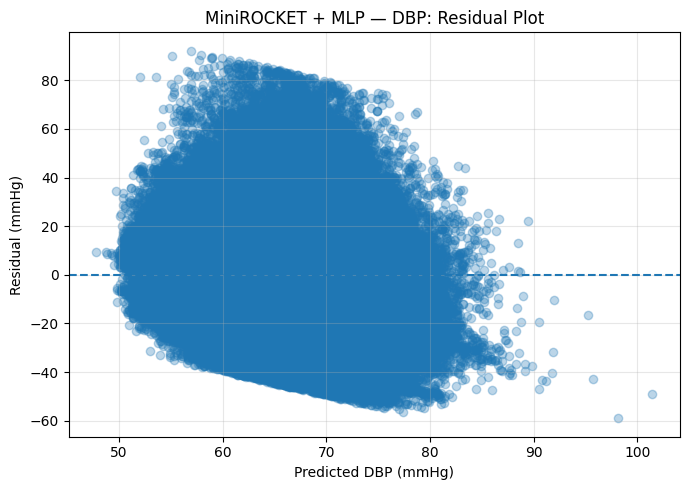

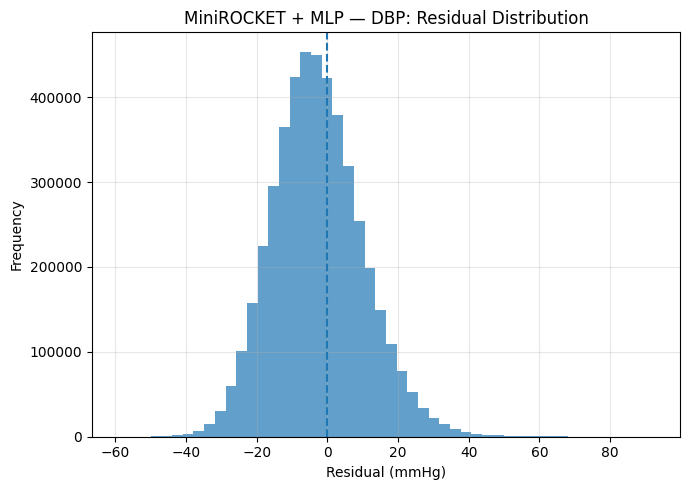

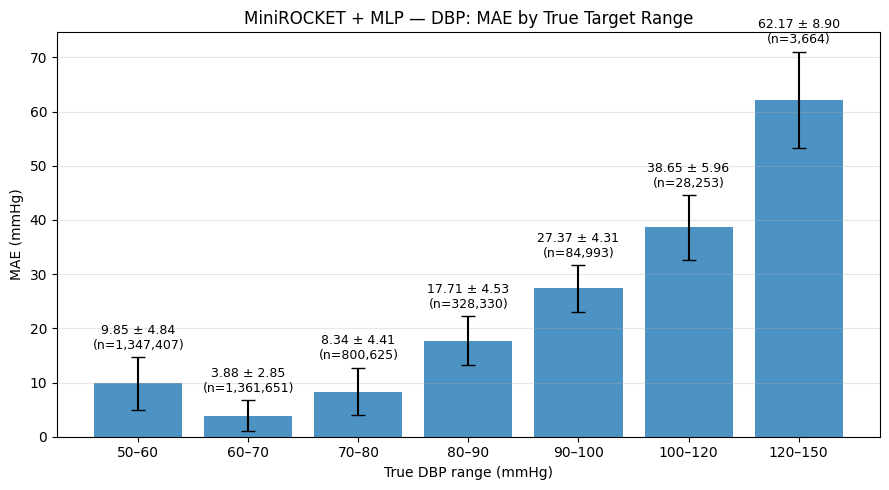


Final prediction shape:
(4651395, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  171.894928  106.433258  75.124176  59.950027
1  case_1  169.920013  109.313461  76.605347  62.167717
2  case_1  168.932587  108.069000  76.111603  62.044926
3  case_1  170.907501  105.078117  74.136719  60.775349
4  case_1  168.932587  105.332039  75.617889  61.166351


In [18]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR, rocket=rocket,
    best_en_sbp=mlp_sbp, best_en_dbp=mlp_dbp, model = "MLP", batch_size=2000)

## Feature Selection ##

In [19]:
sbp_idx, sbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 0],
    k=1000
)

dbp_idx, dbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 1],
    k=1000
)

In [20]:
print("SBP top features:", sbp_idx[:20])
print("SBP correlations:", sbp_corr[:20])

print("DBP top features:", dbp_idx[:20])
print("DBP correlations:", dbp_corr[:20])

SBP top features: [ 435  233  238  385 1453 1082  501  519  997 1543  230  645  553  509
 1448 1788  543 1960 1145  517]
SBP correlations: [ 0.24452914 -0.24344447 -0.24229918 -0.23959872 -0.237176    0.23414293
  0.2334622   0.23323397 -0.23318858  0.23318253 -0.2331614   0.23278786
  0.2325222   0.23232935 -0.23080342 -0.23073135  0.23038454  0.23024479
  0.22846621  0.2281225 ]
DBP top features: [1555 1890  521  234  383  218 1157  388  980 2102  529  210 1225 1496
  239  432 1069 1438 1159 2660]
DBP correlations: [ 0.23162195  0.22374155  0.21782012 -0.21601826 -0.21433659 -0.21285485
  0.21268614 -0.21266782 -0.21223912  0.21176368  0.20938271 -0.20834577
  0.20752597 -0.20733993 -0.2057171   0.20277528 -0.20222837 -0.20093188
  0.19957523 -0.19878152]
